In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('league_data.csv')

df.head()

,game_id,game_start_utc,game_duration,game_mode,game_type,game_version,map_id,platform_id,queue_id,participant_id,...,final_magicPen,final_magicPenPercent,final_magicResist,final_movementSpeed,final_omnivamp,final_physicalVamp,final_power,final_powerMax,final_powerRegen,final_spellVamp
0,3727443167,2025-01-15 14:56:00,1714,CLASSIC,MATCHED_GAME,15.1.649.4112,11,EUN1,420,5,...,0,0,48,385,0,0,799,1134,147,0
1,3726377460,2025-01-13 10:50:00,1300,CLASSIC,MATCHED_GAME,15.1.648.3927,11,EUN1,420,5,...,0,0,38,390,0,0,970,970,105,0
2,3729643655,2025-01-19 18:15:00,2019,CLASSIC,MATCHED_GAME,15.1.649.4112,11,EUN1,420,2,...,0,0,121,431,0,0,10000,10000,0,0
3,3729915593,2025-01-20 01:27:00,1625,CLASSIC,MATCHED_GAME,15.1.649.4112,11,EUN1,420,8,...,12,0,47,380,0,0,1122,1596,37,0
4,3729901665,2025-01-20 00:40:00,1542,CLASSIC,MATCHED_GAME,15.1.649.4112,11,EUN1,420,10,...,0,0,40,534,0,0,1025,1025,109,0


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40410 entries, 0 to 40409
Data columns (total 94 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   game_id                                40410 non-null  int64  
 1   game_start_utc                         40410 non-null  object 
 2   game_duration                          40410 non-null  int64  
 3   game_mode                              40410 non-null  object 
 4   game_type                              40410 non-null  object 
 5   game_version                           40410 non-null  object 
 6   map_id                                 40410 non-null  int64  
 7   platform_id                            40410 non-null  object 
 8   queue_id                               40410 non-null  int64  
 9   participant_id                         40410 non-null  int64  
 10  puuid                                  40410 non-null  object 
 11  su

In [3]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['game_start_utc', 'game_mode', 'game_type', 'game_version',
       'platform_id', 'puuid', 'summoner_name', 'summoner_id', 'champion_name',
       'individual_position', 'team_position', 'lane', 'role', 'solo_tier',
       'solo_rank', 'flex_tier', 'flex_rank',
       'champion_mastery_lastPlayTime_utc'],
      dtype='object')
Numerical: Index(['game_id', 'game_duration', 'map_id', 'queue_id', 'participant_id',
       'summoner_level', 'champion_id', 'team_id', 'kills', 'deaths',
       'assists', 'baron_kills', 'dragon_kills', 'gold_earned', 'gold_spent',
       'total_damage_dealt', 'total_damage_dealt_to_champions',
       'physical_damage_dealt_to_champions', 'magic_damage_dealt_to_champions',
       'true_damage_dealt_to_champions', 'damage_dealt_to_objectives',
       'damage_dealt_to_turrets', 'total_damage_taken',
       'physical_damage_taken', 'magic_damage_taken', 'true_damage_taken',
       'time_ccing_others', 'vision_score', 'wards_placed', 'wards_kill

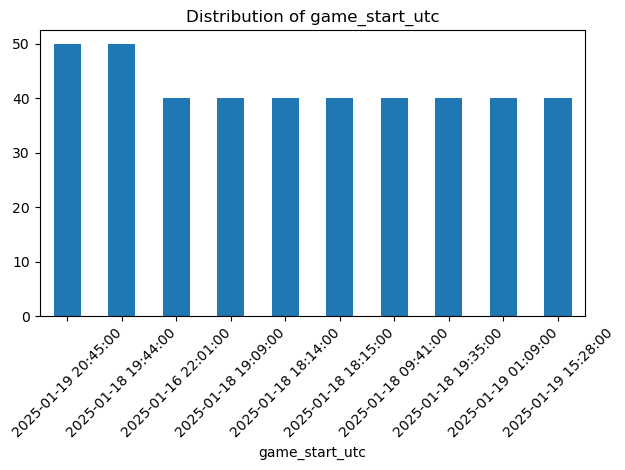

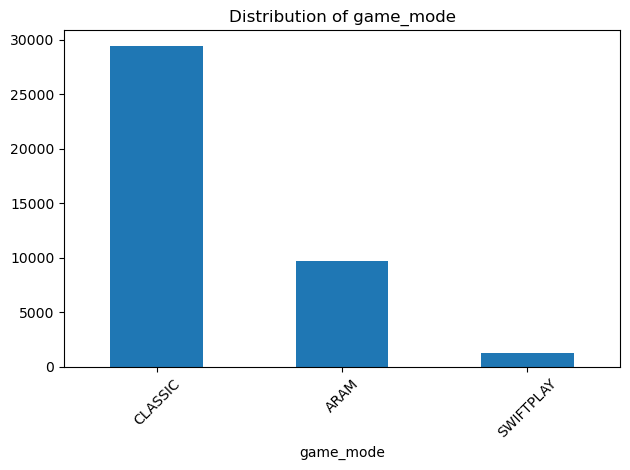

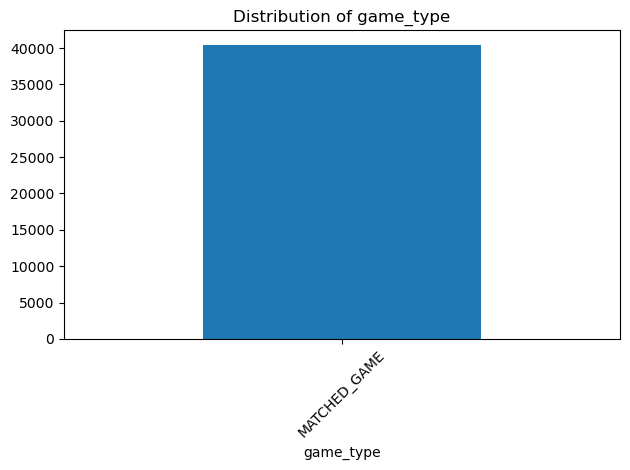

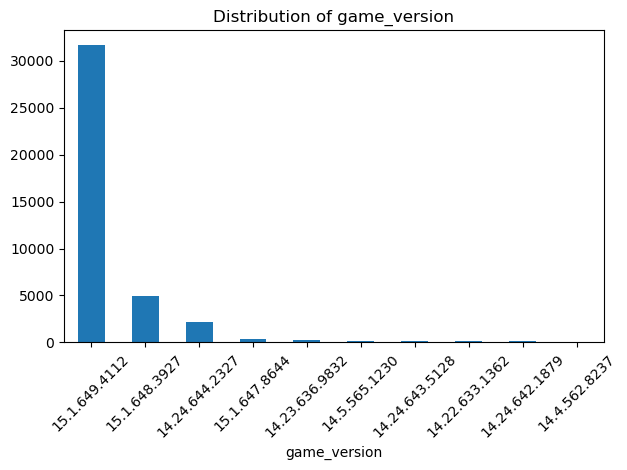

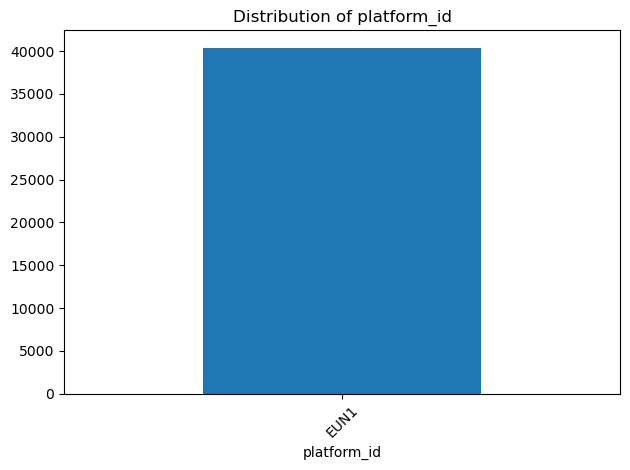

C:\Users\tiany\AppData\Local\Temp\ipykernel_34116\4192598434.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


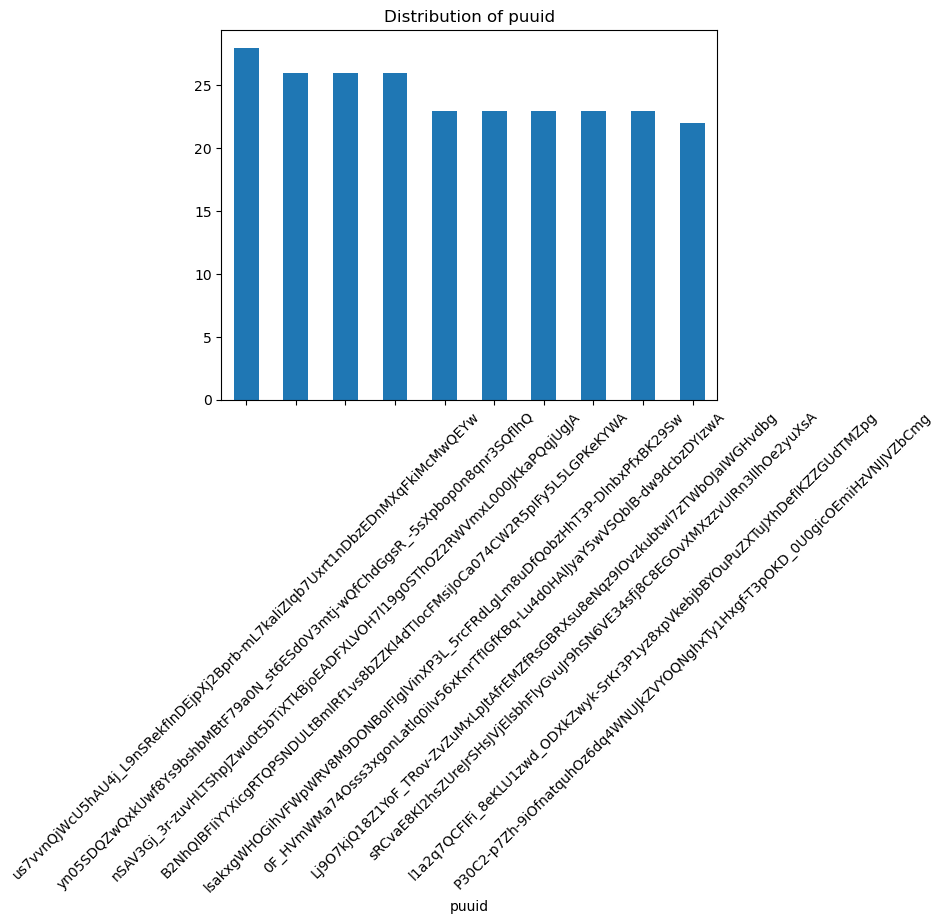

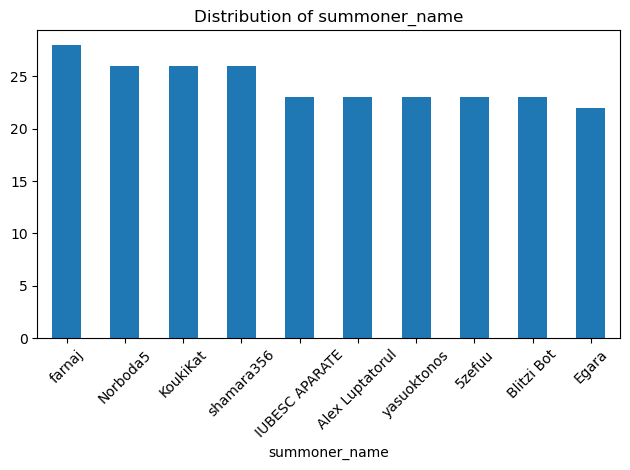

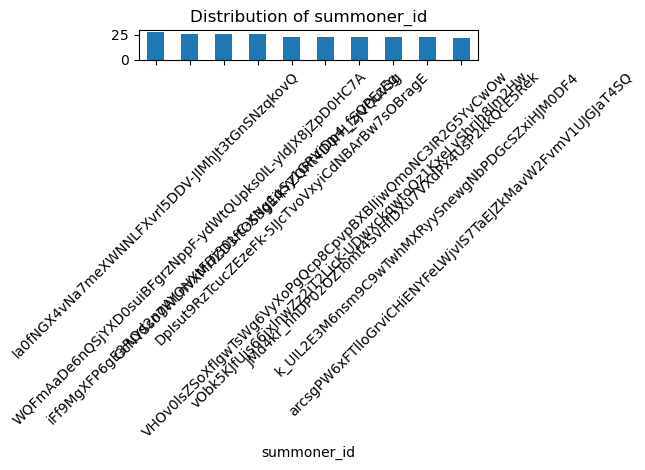

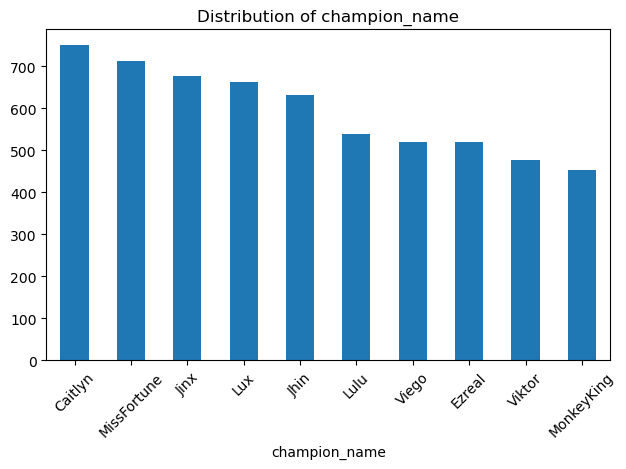

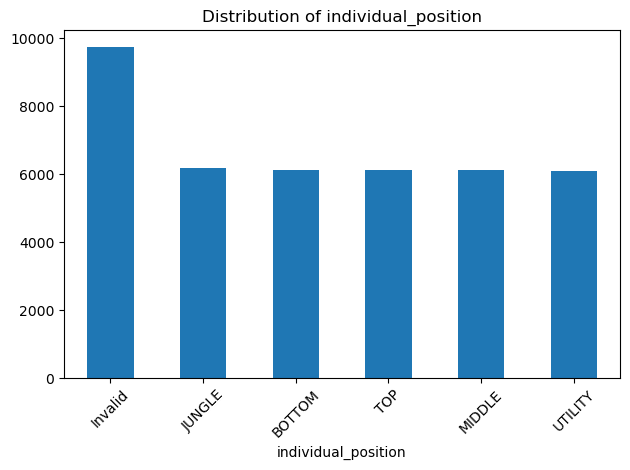

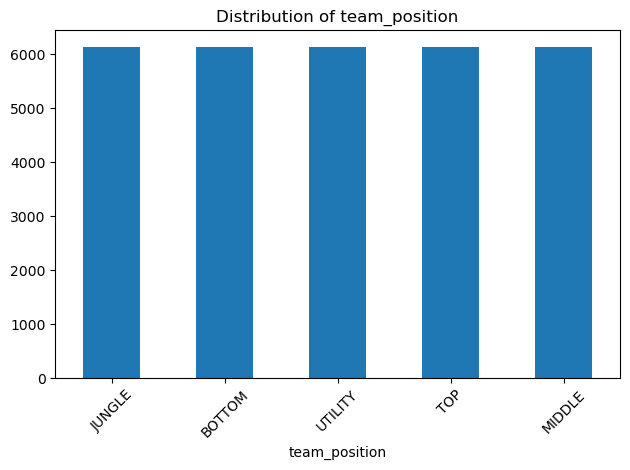

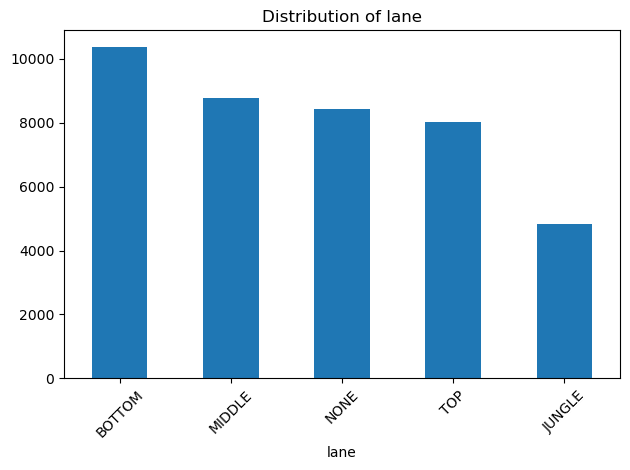

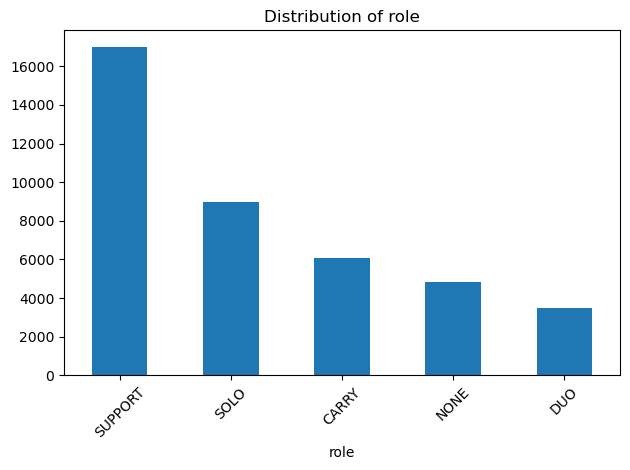

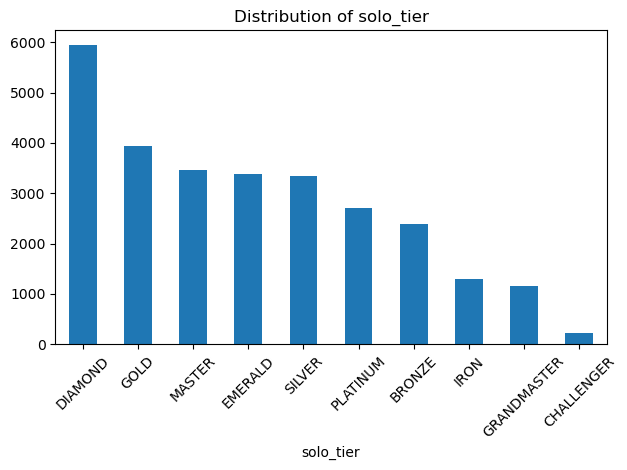

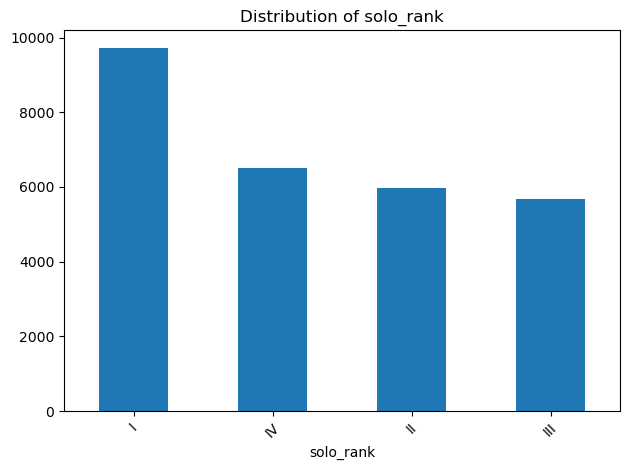

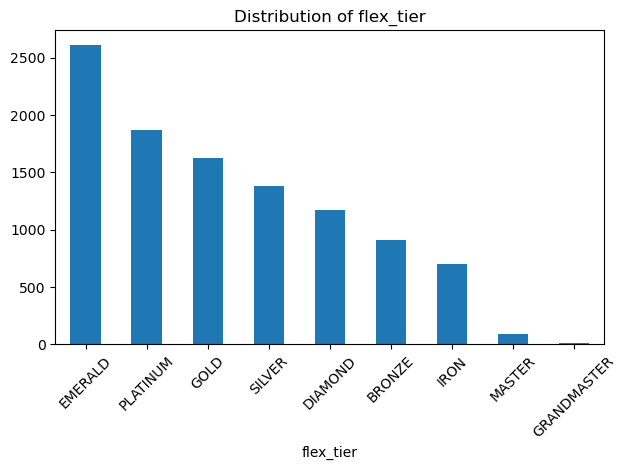

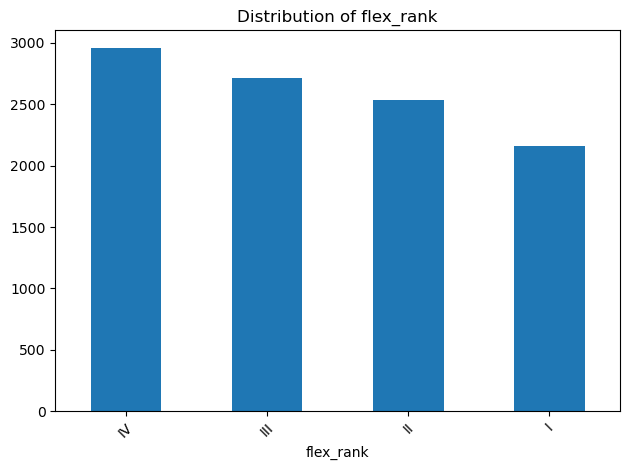

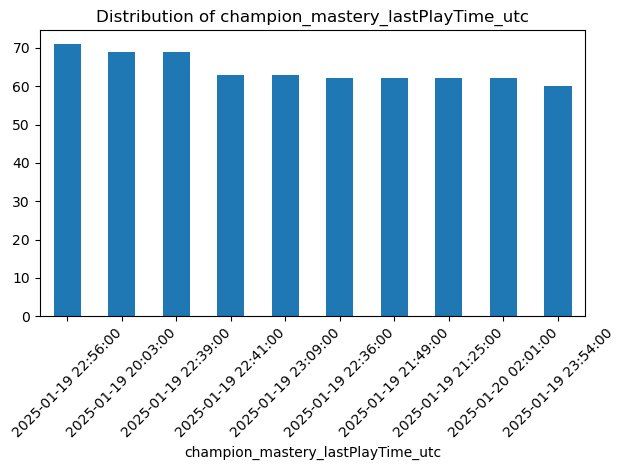

In [4]:
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{col}_bar.png')
    plt.show()

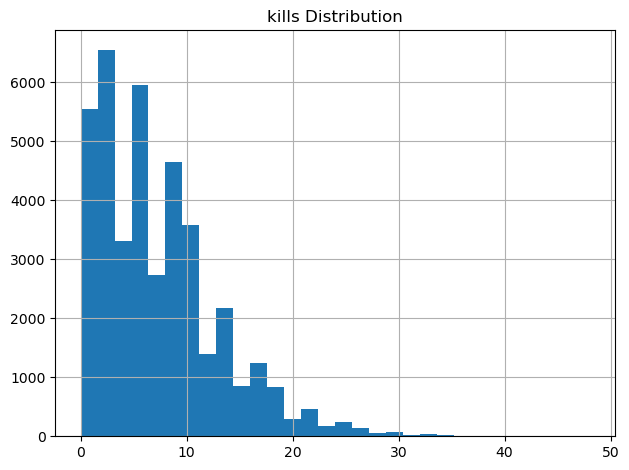

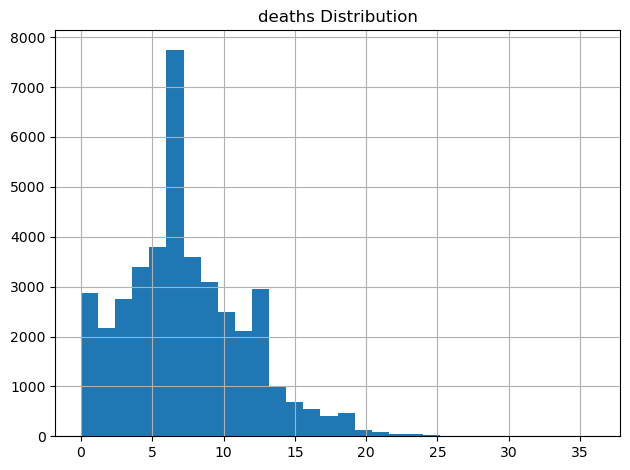

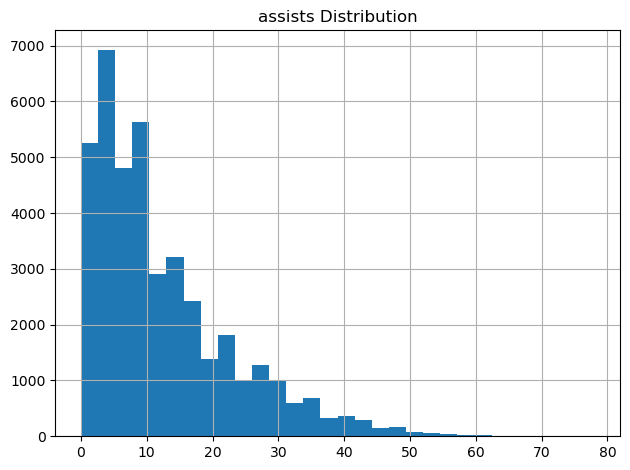

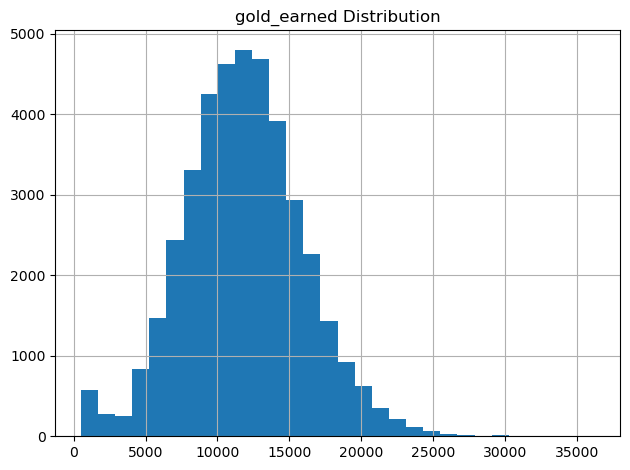

In [5]:
important_cols = ['kills', 'deaths', 'assists', 'gold_earned', 'damage_dealt']

for col in important_cols:
    if col in df.columns:
        plt.figure()
        df[col].hist(bins=30)
        plt.title(f'{col} Distribution')
        plt.tight_layout()
        plt.savefig(f'{col}_important.png')
        plt.show()

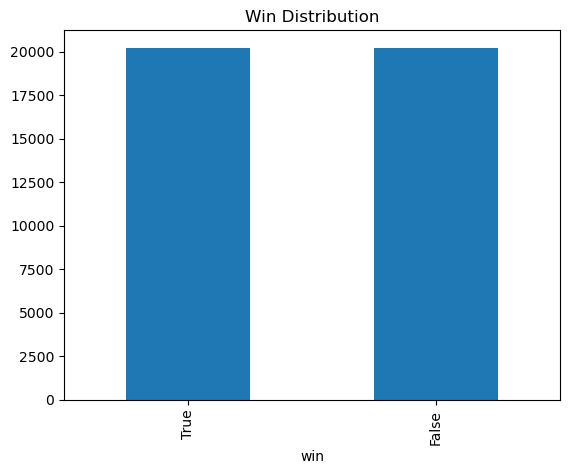

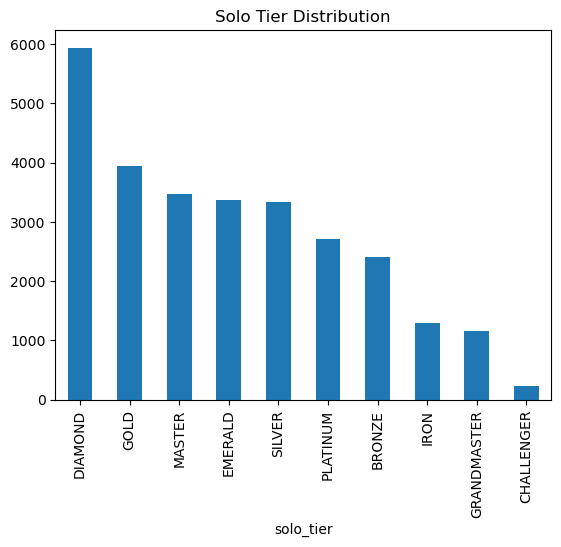

In [6]:
# Binary target
df['win'].value_counts().plot(kind='bar')
plt.title('Win Distribution')
plt.savefig('win_distribution.png')
plt.show()

# Multi-class target
df['solo_tier'].value_counts().plot(kind='bar')
plt.title('Solo Tier Distribution')
plt.savefig('solo_tier_distribution.png')
plt.show()

In [7]:
# Check values first
print(df['win'].unique())

# Keep only valid rows
df = df[df['win'].isin([True, False])]

# Convert to numeric
df['win'] = df['win'].astype(int)

[ True False]


In [8]:
drop_cols = [
    'game_id', 'summoner_id', 'summoner_name',
    'match_id', 'player_id'  # adjust based on your dataset
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [9]:
df = df.dropna()

In [14]:
features = [
    'kills', 'deaths', 'assists',
    'gold_earned', 'gold_spent',
    'total_damage_dealt_to_champions', 'total_damage_taken',
    'vision_score', 'wards_placed',
    'minions_killed', 'champion_mastery_points'
]

features = [col for col in features if col in df.columns]

In [15]:
tier_order = [
    'IRON', 'BRONZE', 'SILVER', 'GOLD',
    'PLATINUM', 'EMERALD', 'DIAMOND',
    'MASTER', 'GRANDMASTER', 'CHALLENGER'
]

df = df[df['solo_tier'].isin(tier_order)]

df['solo_tier_encoded'] = df['solo_tier'].map({
    tier: i for i, tier in enumerate(tier_order)
})

In [16]:
df_binary = df[features + ['win']]
df_multi = df[features + ['solo_tier_encoded']]

In [18]:
df_binary.to_csv('binary_dataset.csv', index=False)
df_multi.to_csv('multiclass_dataset.csv', index=False)